# Hotel Reputation Dashboard — Exploratory Data Analysis

Exploring the processed review dataset (898 reviews, 22 Miami/Orlando hotels) that feeds the
[Plotly Dash dashboard](../dashboard/app.py). See [`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md) for
how sentiment and topic fields were generated.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 100

data_path = Path('..') / 'dashboard' / 'data'
reviews = pd.read_csv(data_path / 'processed_reviews.csv', parse_dates=['published_date'])
reputation = pd.read_csv(data_path / 'reputation_scores.csv')
trends = pd.read_csv(data_path / 'sentiment_trends.csv')

print(f"Reviews: {len(reviews)}")
print(f"Hotels: {reputation['hotel_id'].nunique()}")
reviews.head()

Reviews: 898
Hotels: 22


,review_id,hotel_id,hotel_name,city,review_text,rating,language,sentiment_score,sentiment_label,topic_id,topic_name,trip_type,published_date
0,940920463,235516,AC Hotel Miami Wynwood,Miami,"AC Hotel was in the perfect location for us, s...",5,en,0.942625,positive,-1,Unknown,FAMILY,2024-03-05
1,941788654,235516,AC Hotel Miami Wynwood,Miami,Sheryl at the front desk was so helpful; she h...,5,en,0.757285,positive,-1,Unknown,COUPLES,2024-03-11
2,944421534,235516,AC Hotel Miami Wynwood,Miami,This is one of the best Marriott properties I ...,5,en,0.949654,positive,-1,Unknown,FRIENDS,2024-03-29
3,944698332,235516,AC Hotel Miami Wynwood,Miami,We have titanium statues and Freddy was phenom...,5,en,0.970257,positive,0,hotel,FAMILY,2024-03-31
4,945273189,235516,AC Hotel Miami Wynwood,Miami,"Nice hotel. Large rooms, nice view. Good break...",5,en,0.862820,positive,0,hotel,FAMILY,2024-04-04


## Rating & Sentiment Distributions

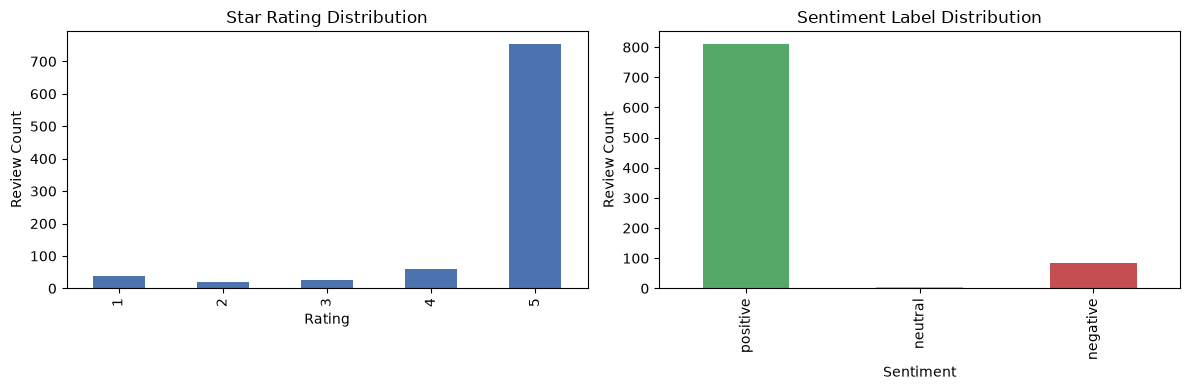

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

reviews['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4c72b0')
axes[0].set_title('Star Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Review Count')

reviews['sentiment_label'].value_counts().reindex(['positive', 'neutral', 'negative']).plot(
    kind='bar', ax=axes[1], color=['#55a868', '#ccb974', '#c44e52']
)
axes[1].set_title('Sentiment Label Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Review Count')

plt.tight_layout()
plt.show()

Ratings and sentiment agree closely (both skew strongly positive), which is expected — sentiment was
derived from review text, not the star rating, so this cross-validates the sentiment model rather than
being circular.

## Reputation Score by Hotel

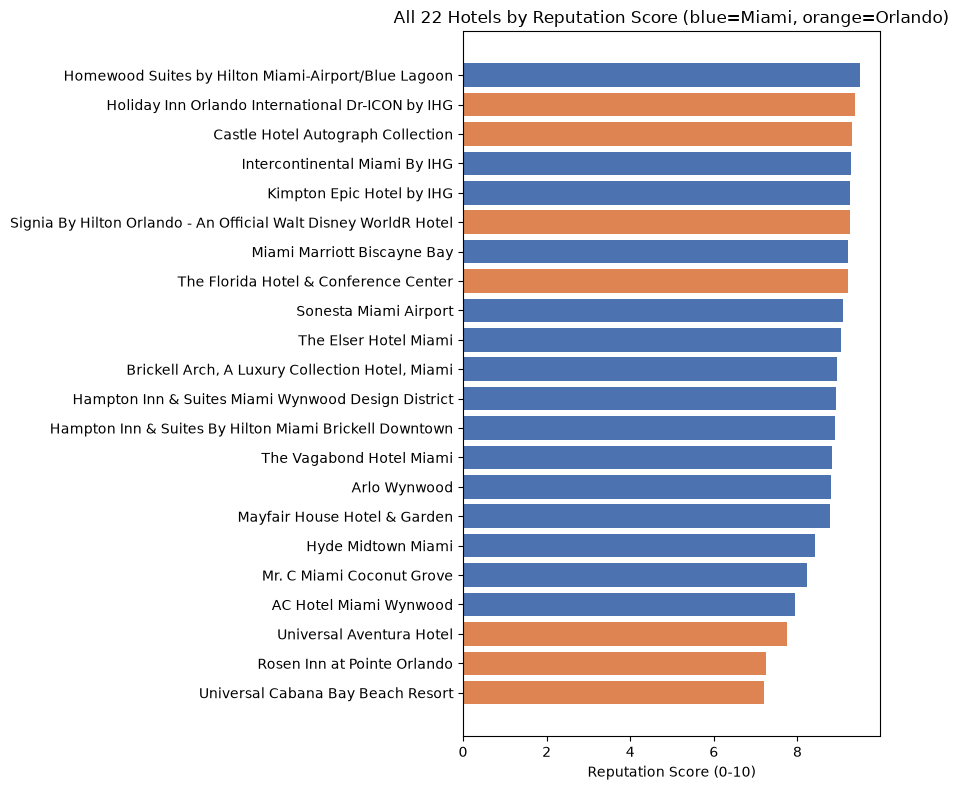

In [3]:
fig, ax = plt.subplots(figsize=(9, 8))

ranked = reputation.sort_values('reputation_score')
colors = ['#4c72b0' if c == 'Miami' else '#dd8452' for c in ranked['city']]

ax.barh(ranked['hotel_name'], ranked['reputation_score'], color=colors)
ax.set_xlabel('Reputation Score (0-10)')
ax.set_title('All 22 Hotels by Reputation Score (blue=Miami, orange=Orlando)')
plt.tight_layout()
plt.show()

In [4]:
reputation.groupby('city')['reputation_score'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
city,,,
Miami,8.88,0.42,15
Orlando,8.48,1.02,7


Miami's average reputation score is higher than Orlando's, but Orlando's sample (7 hotels) is under
half the size of Miami's (15 hotels) — see [`data/README.md`](../data/README.md#coverage-note) for why.
The Orlando comparison should be read as preliminary until the dataset is expanded.

## Sentiment Trend Over Time

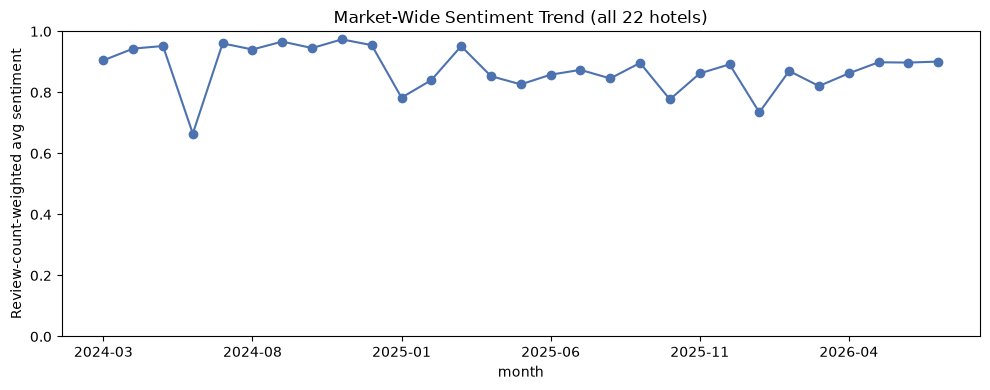

In [5]:
monthly = trends.groupby('month').apply(
    lambda g: (g['avg_sentiment'] * g['review_count']).sum() / g['review_count'].sum()
).rename('avg_sentiment')

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker='o', color='#4c72b0')
ax.set_ylim(0, 1)
ax.set_ylabel('Review-count-weighted avg sentiment')
ax.set_title('Market-Wide Sentiment Trend (all 22 hotels)')
plt.tight_layout()
plt.show()

## Top Topics

618 / 898 reviews assigned to a topic (280 in BERTopic's outlier bucket)


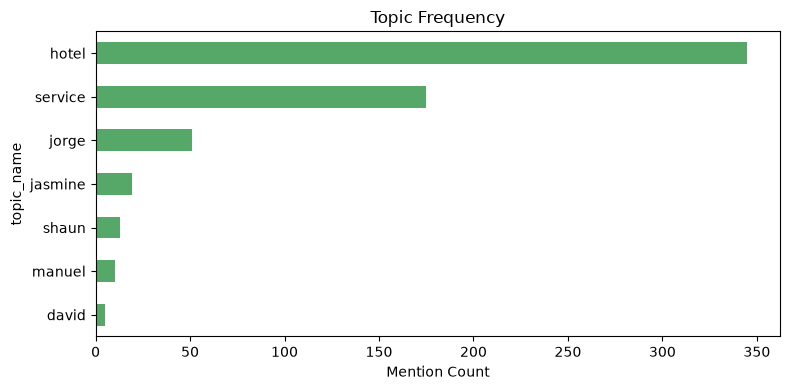

In [6]:
clustered = reviews[reviews['topic_id'] >= 0]
print(f"{len(clustered)} / {len(reviews)} reviews assigned to a topic "
      f"({len(reviews) - len(clustered)} in BERTopic's outlier bucket)")

fig, ax = plt.subplots(figsize=(8, 4))
clustered['topic_name'].value_counts().plot(kind='barh', ax=ax, color='#55a868')
ax.set_xlabel('Mention Count')
ax.set_title('Topic Frequency')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Most topics resolve to individual staff members' names (guests frequently shout out specific front-desk
staff by name), plus generic "hotel"/"service" terms — a realistic pattern for hospitality reviews.

## Summary

- Sentiment (812 positive / 83 negative / 3 neutral) tracks star ratings closely, validating the
  zero-shot sentiment model against an independent signal.
- **Homewood Suites by Hilton Miami-Airport/Blue Lagoon** (9.50/10) and **Holiday Inn Orlando
  International Dr-ICON by IHG** (9.37/10) top their respective city rankings.
- Staff service is the dominant praise driver across both markets.
- Next steps: expand the Orlando sample and add Spanish-language coverage (see
  [`docs/METHODOLOGY.md#known-limitations`](../docs/METHODOLOGY.md#known-limitations)).